In [13]:
import os
os.environ["KERAS_BACKEND"] = "torch"   # keras/tensorflow import 전에!

import keras, torch
print("backend :", keras.backend.backend())   # torch 나와야 GPU
print("cuda    :", torch.cuda.is_available())

backend : torch
cuda    : True


### 이미지 데이터 활용
- 실제 이미지 데이터를 가지고 모델에 학습을 진행
- 이미지 데이터는 그대로 사용할수 없고, 픽셀 단위로 나눠서 숫자로 변환하는 작업 필요
 - openCV에서 제공하는 read_img
 - tensorflow에서 제공하는 image_dataset_from_directory

In [14]:
# 데이터분석에 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 이미지를 수치화하기 위해 폴더에 접근하여 이미지를 읽어올수 있도록 도와주는 도구 불러오기
from tensorflow.keras.utils import image_dataset_from_directory

# 반복문을 사용할 때 진행상황을 보여주는 도구 불러오기
from tqdm import tqdm

In [15]:
train_img = image_dataset_from_directory(
    directory = './data/animal/animal_small',
    # 폴더명 -> 정수 라벨링
    labels = 'inferred',
    # 다중분류이기 때문에 원핫인코딩을 해야하는데 자동으로 해주도록 설정
    label_mode = 'categorical',
    # 색상 채널 설정
    color_mode = 'rgb',
    # 이미지 사이즈 설정
    image_size = (224, 224),
)

Found 2000 files belonging to 4 classes.


In [16]:
# 문제데이터(X), 정답데이터(y)를 분리하기 위해 직접 집어넣기
X_train = []
y_train = []

# train_img 에서 배열값을 뽑아 우리가 원하는 img데이터, label 데이터 추출해서 집어넣기
for img, label in train_img.as_numpy_iterator():
    X_train.append(img)
    y_train.append(label)

In [17]:
# 리스트에 담겨있는 정보를 활용하여 배열형태로 넣기
X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

In [18]:
# 데이터 크기 확인
X_train.shape, y_train.shape

((2000, 224, 224, 3), (2000, 4))

### MLP 층으로 인공신경망 설계(모델링)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Rescaling
from tensorflow.keras.optimizers import Adam

In [20]:
# 1. 신경망 구조 설계
# 뼈대 생성
model = Sequential()
# 입력층 - 입력데이터의 형태에 맞도록!  (224, 224, 3) : rgb라서 채널 3
model.add(InputLayer(shape=(224, 224, 3)))
# ★ 픽셀값 0~255 -> 0~1 스케일링 (주석 처리하면 학습이 거의 안 됨)
model.add(Rescaling(1./255))
# 1차원으로 평평하게 만들어주는 부분(flatten)
model.add(Flatten())
# 중간층 1 - 뉴런 64, 활성화함수 relu
model.add(Dense(64, activation='relu'))
# 중간층 2 - 뉴런 64, 활성화함수 relu
model.add(Dense(64, activation='relu'))
# 중간층 3 - 뉴런 64, 활성화함수 relu
model.add(Dense(64, activation='relu'))
# 출력층 - 다중분류(범주가 몇개인지) : cat/dog/sheep/squirrel -> 4개
model.add(Dense(units = 4, activation='softmax'))

# 2. 학습방법 및 평가방법 설정
# 다중분류 -> 손실함수 / 최적화함수 : adam / 평가지표 : 정확도
# ★ 'adam' 으로만 쓰면 기본 학습률 0.001이 적용되는데, 입력이 150528개나 되는
#    이 구조에선 너무 커서 첫 배치에 발산해버림(loss 12 고정, 정확도 25%).
#    반드시 Adam(learning_rate=0.0001) 형태로 낮춰서 써야 학습됨
model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     9,633,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,642,436 (36.78 MB)

 Trainable params: 9,642,436 (36.78 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# 3. 학습
# epoch : 20, 검증용 데이터 - 훈련데이터의 2/10
# validation_split=0.2 -> 훈련데이터에서 20%를 검증용으로 떼어냄
h = model.fit(
    X_train, y_train,
    epochs = 20,
    validation_split = 0.2
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.3000 - loss: 1.6099 - val_accuracy: 0.3575 - val_loss: 1.4223
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.3425 - loss: 1.3721 - val_accuracy: 0.3800 - val_loss: 1.3057
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4275 - loss: 1.2771 - val_accuracy: 0.4225 - val_loss: 1.2752
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4231 - loss: 1.2733 - val_accuracy: 0.3525 - val_loss: 1.3200
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4600 - loss: 1.2369 - val_accuracy: 0.3975 - val_loss: 1.2655
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.4731 - loss: 1.1981 - val_accuracy: 0.4275 - val_loss: 1.2695
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4669 - loss: 1.1975 - val_accuracy: 0.3625 - val_loss: 1.4081
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4719 - loss: 1.1980 - val_accuracy: 0.4650 - v

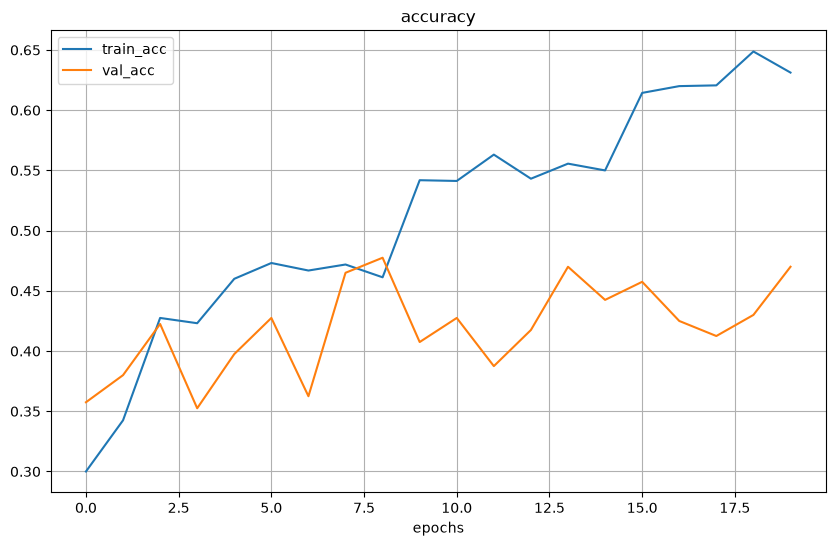

In [26]:
# 4. 결과 시각화
plt.figure(figsize=(10, 6))

# 정확도
plt.plot(h.history['accuracy'], label='train_acc')
plt.plot(h.history['val_accuracy'], label='val_acc')
plt.title('accuracy')
plt.xlabel('epochs')
plt.legend()
plt.grid(True)

plt.show()

### CNN 구조


In [27]:
# CNN 쌓기 위한 도구 불러오기
from tensorflow.keras.layers import Conv2D, MaxPooling2D

In [ ]:
# 1. 신경망 설계(CNN)
# 뼈대 생성
cnn_model = Sequential()

# 입력층
cnn_model.add(InputLayer(shape=(224,224,3)))

# 특성추출부(CNN)
# Conv : 특징 추출하는 층
cnn_model.add(Conv2D(
    # 필터(커널)의 개수 설정
    filters=64,
    # 필터(커널)의 크기 조절 (무조건 홀수로 사용)
    kernel_size=(3,3),
    # 패딩 설정
    # 가장 자리에 중요한 정보가 들어있는 데이터의 경우
    # 패딩 사용하는 것이 유리
    # 하지만 그렇지 않은경우 연산량 때문에 소모 자원이 많아져서 적절하게 사용
    padding='same', # same : 패딩 사용 / valid : 패딩사용x
    # 활성화 함수
    activation='relu'
))
# Pooling : 중요한 특징만 걸러주는 층
cnn_model.add(MaxPooling2D())

# Conv : 특징 추출하는 층
cnn_model.add(Conv2D(
    # 필터(커널)의 개수 설정
    filters=64,
    # 필터(커널)의 크기 조절 (무조건 홀수로 사용)
    kernel_size=(3,3),
    # 패딩 설정
    # 가장 자리에 중요한 정보가 들어있는 데이터의 경우
    # 패딩 사용하는 것이 유리
    # 하지만 그렇지 않은경우 연산량 때문에 소모 자원이 많아져서 적절하게 사용
    padding='same', # same : 패딩 사용 / valid : 패딩사용x
    # 활성화 함수
    activation='relu'
))
# Pooling : 중요한 특징만 걸러주는 층
cnn_model.add(MaxPooling2D())

# Flatten (1차원으로 변환!)
cnn_model.add(Flatten())

# 분류부(MLP)
# 중간층(은닉층)
# 중간층3 - 뉴런 개수 64개, 활성화함수 relu
cnn_model.add(Dense(units=64, activation='relu'))
cnn_model.add(Dense(units=64, activation='relu'))
cnn_model.add(Dense(units=64, activation='relu'))

# 출력층
cnn_model.add(Dense(units=4, activation='softmax'))